## Law of large numbers
대수의 법칙(Law of Large Numbers, LLN)은
표본의 크기(시도 횟수)가 커질수록 표본의 평균이 모집단의 진짜 평균(기댓값)에 가까워진다는 확률론의 핵심 정리입니다(제미나이).

Colab. 보여주자. 확인하자.

In [1]:
# _lln_00.py
# law of large number, 오차의 크기

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import scipy as sci
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


In [2]:
# 필요한 파라메터 설정
# 표본 크기 지정, beg부터 end까지 stp 간격.
# 1000 부터 1000 간격으로 11000까지. 마지막은 포함하지 않으므로, 총 10개 경우임.
size_beg = 1000
size_end = 11000
size_stp = 1000

# number of iterations, monte carlo simulation given sample size.
n_itr = 1356    # 주어진 표본크기에서 n_itr 만큼 반복.실험.

# 임의변수 생성, 균등분포, 정규분포.
seed = 135678942   # 시드

# 균등분포 시작, 끝, 분산 = (b-a)^2/12 =약 225.33, 표편 약 15.01
x_beg = 74
x_end = 126

# 정규분포라면 이렇게.
mu = 100
sig = 15


 $ X_i \sim U(a, b) $이면(균등분포),  
$$ E(X_i) = { a + b \over 2} , \quad  Var (X_i) = {(b-a )^2 \over 12} $$

$ a=74, b= 126 $일 때, $ \mu=100,\ \sigma^2 =225.3,\ \sigma = 15.01 $.

for large $ n $,
$$ \bar X \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \bar X $의 평균 100, 표준오차 $ 15.01 \over \sqrt n $.

$ n=1000 \to SE =0.474 $,  $ n=10000 \to SE = 0.15 $, ...  

 $ X_i =1,\cdots, 6 \ with\ p={1 \over 6} $(주사위 실험),  
$$ E(X_i) = 3.5 , \quad  Var (X_i) = {35 \over 12}\approx 2.92 $$

$ \mu= 3.5,\ \sigma^2 =2.92,\ \sigma = 1.71 $.

for large $ n $,
$$ \bar X \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \bar X $의 평균 3.5, 표준오차 $ 1.71 \over \sqrt n $.

$ n=1000 \to SE =0.054 $,  $ n=10000 \to SE = 0.017 $, ...  

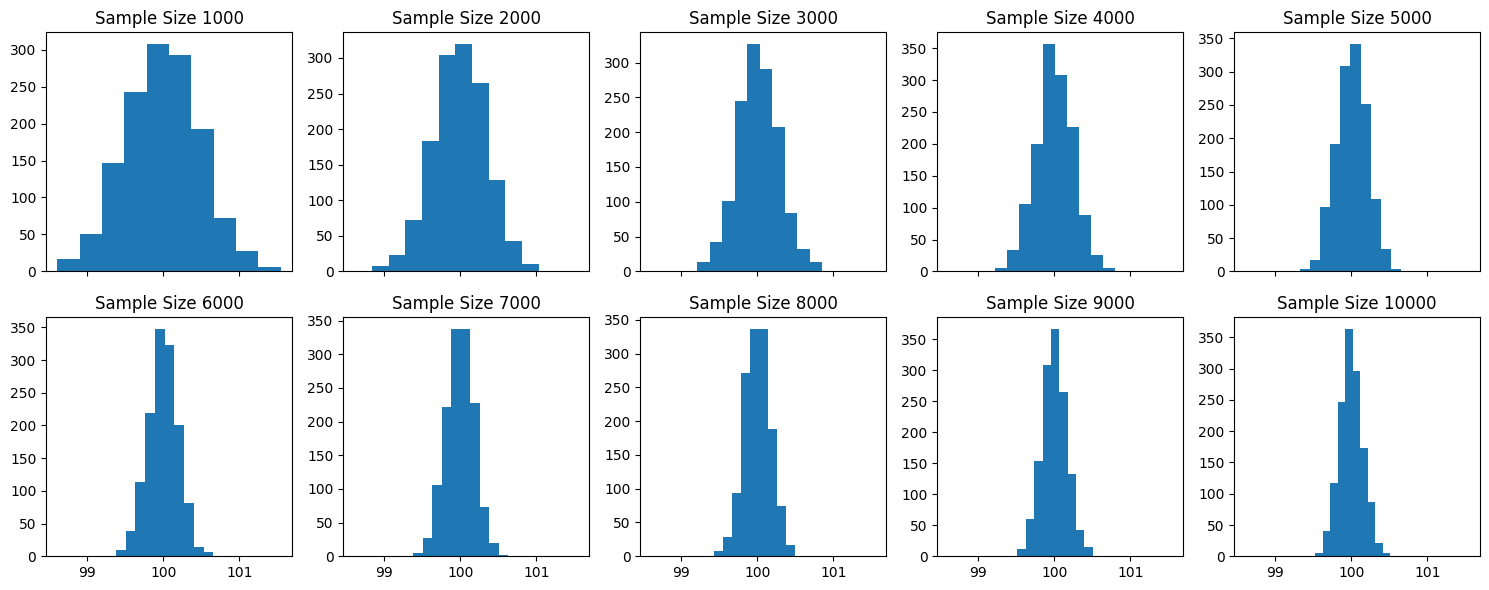

In [3]:
# 1. 데이터 준비. 읽기. 생성. random number
rng = np.random.default_rng(seed)

# 2. 그림(서브플롯) 생성 준비.
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), sharex=True)

# 2.1. 2차원 배열인 axes를 1차원(10개)으로 평평하게 폄.
axes = axes.flatten()

# 1.1. 계산 결과를 담을 리스트. 여기에 표본 평균을 담음.
## 표본 크기에서 모의실험 결과 정리. 표본크기, 평균의 평균, 평균의 표준편차
muhat_rslt = []

# 3. 반복문 실행. 이건 일종의 따블 반복문. k, i,
for sub_i, k in enumerate(np.arange(size_beg, size_end, size_stp)):
    # 서브플롯 순서를 sub_i로 받음.
    # for k in np.arange(size_beg, size_end, size_stp):
    # # a에서 b까지 c씩 증가, 끝은 포함하지 않음. 인텍스 k.
    n_smpl = k

    # 각 서브플롯 선택, enumerate 인덱스 sub_i로 받음.
    ax = axes[sub_i]

    # 표본 크기 고정. 평균 관측치 묶음. 234회 => 평균치 234개, n_itr 개
    muhat = []

    # 반복문(인덱스 k) 내 반복문(인덱스 i)임.
    for i in np.arange(0, n_itr, 1) :  # 0에서 itr까지 1씩 증가
        # x = rng.normal(loc=mu, scale=sig, size=n_smpl)  # obs tbg
        x = rng.uniform(x_beg, x_end, n_smpl)
        muhat.append(np.mean(x)) # 매회 muhat 계산, 반복할 때 추가, append.

    # 서브플롯 생성(반복문 i 바깥, 반복문 k 내부)
    ax.hist(muhat)               # n_smpl = 1000, n_itr = 2345 반복시 평균 분포 히스토그램(상자그림 가능)
    ax.set_title(f'Sample Size {k}') # n_smpl 별 서브플롯
    #plt.show()

    # 서브 계산(인덱스 k): 표본 크기, 평균, 표준오차, 쌓아 올림.
    muhat_mean = np.mean(muhat)     # 표본 크기 고정, n_itr 반복 평균치의 평균. for i 바깥임. 끝난 후.
    muhat_std = np.std(muhat, ddof=1)
    muhat_rslt.append( [n_smpl, muhat_mean, muhat_std] )  # 표본 크기마다 계산된 통계치 쌓음.
                                                             # n의 크기와 평균의 평균, 평균의 표준편차
                                                             # 최종 산출물, 관심 대상.
    # 여기까지 인덱스 k 진행중. 인덱스 i 벗어남.

# 인텍스 k 벗어남. 최종 결과들.
# 4. 서브플롯들끼리 겹치지 않게 여백 자동 조정
# 표본 크기가 증가하면 히스토그램이 중심으로 붕괴한다. 확인.
plt.tight_layout()
plt.show()


## 그래프에서 확인할 수 있는 것은?
표본 평균이 분포를 보인다는 것.

분포의 중심은 여전하지만, 펼침은 좁아진다.

표본 평균은 모 평균으로 수렴한다.

$$ \bar X, \hat \mu \to \mu $$

In [4]:

# 5. 서브 계산치 인쇄.
# 표본 크기가 증가하면 표본평균의 표준오차는 0으로, 즉, 모평균에 접근, 확인.
muhat_rslt = np.array(muhat_rslt)   # numpy 배열로 전환.
np.set_printoptions(suppress=True, precision=4)
print(muhat_rslt)                   # 포맷, 배열 형식 차이 확인...
# print(f"{muhat_rslt:f}")  # 이것은 배열이나 numpy array에서 안됨, 숫자 1개일 때 적용.


[[ 1000.        99.988      0.4891]
 [ 2000.        99.9934     0.3449]
 [ 3000.       100.0129     0.2699]
 [ 4000.       100.0017     0.2403]
 [ 5000.       100.0084     0.2032]
 [ 6000.        99.9953     0.1941]
 [ 7000.        99.9939     0.1809]
 [ 8000.       100.001      0.1719]
 [ 9000.        99.998      0.163 ]
 [10000.        99.9974     0.1493]]


## 표본 크기가 증가하면, 표준오차(맨 오른쪽)는 감소한다.
극단적으로 0에 접근.

In [5]:

# 다블 반복. 아이디어.
# 표본크기 100, 200, 400, 이런 식으로...  k, n_pop으로 받음
# 표본 크기 100일 때, 250회 실험. i, 1,2,... 이렇게 반복 인덱스임. 계산에 투입되는 것은 아님.
#    평균(통계치) 계산 (매 반복).
#    반복 마다 평균(통계치) 달라짐, 변화, 즉 변수,
#    250회 반복 => 총 250개의 통계치 계산. ==> 평균은 분포를 보임.
#    250회 반복 마지막, 250개 결과값 배열, 반복 루프 밖에 묶음 배열 반환.
#    루프 밖에서 250 결과값의 평균(평균의 평균), 표준편차(평균의 표준편차/표준오차) <== 관심 결과값.
# 표본 크기 200 일 때, 위 실험 반복.
#    위 관심 결과값 채집. 추가. append.
# 표본 크기 변화해 가며 관심결과 채짐, 추가, append.
# 표본 크기 루프 마치면, 루푸 밖에 관심 결과값 배열 반환.
#    반환된 배열로 확인 시도.
#    표본 크기와 (평균의 평균, 평균의 표준편차.표준오차)가 어떤 관계일까.
#      크면, 표준편차가 작아진다는 것을 보여라.
# 그래야 평균이 모평균에 가까워진다는 것을 보인다.
# 그 때 히스토그램 변화 모습을 보여준다.

    # plt.scatter(muhat_rslt.iloc[:,0], muhat_rslt.iloc[:,1])  # data frame에서 열 지정이네.
    # plt.plot(muhat_rslt.iloc[:,0], muhat_rslt.iloc[:,1])
#    plt.scatter(muhat_rslt[:,0], muhat_rslt[:,1])  # numpy 배열에서 열 지정.
#    plt.ticklabel_format(axis='y', style='plain', useOffset=False)
#    plt.show()

#    plt.plot(muhat_rslt[:,0], muhat_rslt[:,1])
#    plt.show()

# 5. 저장
#  저장 파일 이름 지정
    # saved_path = save_chart(
    #     fname = output_fig_file,  # 메인() 밖에서 지정 'sta_09001_corr_01.png'
    #     outdir = output_fig_dir, # 메인() 밖에서 지정 'figures',
    #     fig=fig,
    #     dpi=300)

# 6. 코드 체크
#  변수 특성, 배열 형식, 계산 완료 등.
    #print(saved_path) # for checking
    #      figures\sta_09001_corr_01.png <-- 이게 saved_path 야.
    #      output_fig_dir + output_fig_file 결합이군.
#    print('Saved figure to', saved_path)
print("Computing OK")
#    plt.show()



Computing OK
